In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/train.csv', engine='python')

In [7]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1.0,2.0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0.0
1,1,3.0,4.0,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0.0
2,2,5.0,6.0,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0.0
3,3,7.0,8.0,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0.0
4,4,9.0,10.0,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0.0


In [8]:
df.shape

(148145, 6)

In [9]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
145576,145576,230157.0,230158.0,How does a WAMP Client-Server Andoid applicati...,Can I install a WAMP server on an Android device?,0.0
73478,73478,126088.0,126089.0,How many medals has India won in Olympics till...,How many atheletes from India have won medals ...,1.0
77941,77941,132995.0,132996.0,How can I start gyming?,How do I start gyming at home?,0.0
99228,99228,108610.0,15502.0,Is it safe to browse the dark web?,Is the dark web safe to browse?,1.0
117644,117644,138229.0,7918.0,How can I learn & speak & write English?,How can learn English?,1.0
143558,143558,210430.0,227428.0,What the best anime you see?,What is the best animation you created?,0.0
92373,92373,109999.0,60896.0,How do you recover your gmail account password?,How do I recover my Gmail account when the rec...,1.0
98284,98284,107191.0,6110.0,What are some mind blowing gadgets that exist ...,What are some mind blowing technology gadgets ...,1.0
55687,55687,98146.0,98147.0,"I am doing graduation in management so, I want...","I am just finishing high school, and all my ot...",0.0
130971,130971,210084.0,210085.0,I want to put two divs in HTML in the same lin...,"In HTML, how do you put two tables side by side?",0.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148145 entries, 0 to 148144
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            148145 non-null  int64  
 1   qid1          148144 non-null  float64
 2   qid2          148144 non-null  float64
 3   question1     148144 non-null  object 
 4   question2     148143 non-null  object 
 5   is_duplicate  148144 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 6.8+ MB


In [11]:
df.isnull().sum()

,0
id,0
qid1,1
qid2,1
question1,1
question2,2
is_duplicate,1


In [12]:
df.duplicated().sum()

np.int64(0)

is_duplicate
0.0    93009
1.0    55135
Name: count, dtype: int64
is_duplicate
0.0    62.782833
1.0    37.217167
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

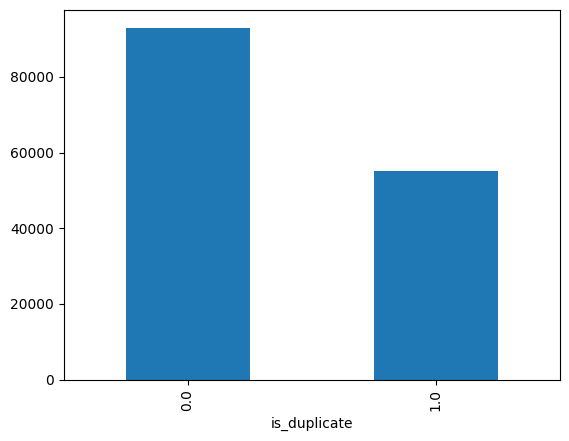

In [13]:
#Distribution oif duplicate and non duplicate question

print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [14]:
df['is_duplicate'].value_counts()

,count
is_duplicate,
0.0,93009
1.0,55135


In [15]:
df['is_duplicate'].count()

np.int64(148144)

In [16]:
# Repeated questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 233649
Number of questions getting repeated 32563


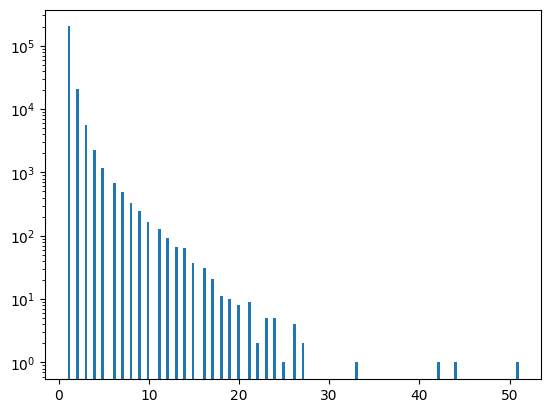

In [17]:
# Repeated questions histogram

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

# **Only Bow**

In [18]:
new_df = df.sample(30000)

In [19]:
new_df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [20]:
new_df.duplicated().sum()

np.int64(0)

In [21]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
121827,How could the U.S. reform its education system?,Will the United States ever reform their educa...
117788,Can meth use be controlled by taking Ativan an...,How long does meth stay detectable in the body...
24566,What do Balaji Viswanathan and Khalid Elhassan...,What does Balaji Viswanathan think about Qnet?
147532,What would happen if Earth lost its gravity fo...,Lets say that gravity turned off for 5 minutes...
41716,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my American Staffy/Kelpie mix afraid of...


In [23]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)

In [24]:
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [25]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)

In [26]:
temp_df.shape

(30000, 6000)

In [27]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
121827,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
117788,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24566,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
147532,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41716,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72045,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
113266,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
143799,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
125614,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
temp_df['is_duplicate'] = new_df['is_duplicate']

In [29]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
121827,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
117788,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
24566,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
147532,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
41716,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0


In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

In [33]:
accuracy_score(y_test,y_pred)

0.7416666666666667

In [34]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7348333333333333

- **Feature Engeneering **

q1 len-> char length of q1

q2 len-> char length of q2

q1 words-> unique words in q1

q2 words -> unique words in q2

words common-> no. of common unique words

words total -> Total unique words in q1+q2

words share -> words common/ words total




In [35]:
import warnings
warnings.filterwarnings('ignore')

In [36]:
# Repeated questions

qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 55315
Number of questions getting repeated 3452


In [37]:
# Feature Engineering

new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [38]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
121827,121827,197325.0,102525.0,How could the U.S. reform its education system?,Will the United States ever reform their educa...,1.0,47,58
117788,117788,141499.0,59325.0,Can meth use be controlled by taking Ativan an...,How long does meth stay detectable in the body...,0.0,148,63
24566,24566,45885.0,45886.0,What do Balaji Viswanathan and Khalid Elhassan...,What does Balaji Viswanathan think about Qnet?,0.0,67,46
147532,147532,23076.0,194310.0,What would happen if Earth lost its gravity fo...,Lets say that gravity turned off for 5 minutes...,1.0,105,100
41716,41716,16923.0,48610.0,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my American Staffy/Kelpie mix afraid of...,1.0,58,52


In [39]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
121827,121827,197325.0,102525.0,How could the U.S. reform its education system?,Will the United States ever reform their educa...,1.0,47,58,8,9
117788,117788,141499.0,59325.0,Can meth use be controlled by taking Ativan an...,How long does meth stay detectable in the body...,0.0,148,63,27,11
24566,24566,45885.0,45886.0,What do Balaji Viswanathan and Khalid Elhassan...,What does Balaji Viswanathan think about Qnet?,0.0,67,46,11,7
147532,147532,23076.0,194310.0,What would happen if Earth lost its gravity fo...,Lets say that gravity turned off for 5 minutes...,1.0,105,100,19,20
41716,41716,16923.0,48610.0,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my American Staffy/Kelpie mix afraid of...,1.0,58,52,9,9


In [40]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [41]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
121827,121827,197325.0,102525.0,How could the U.S. reform its education system?,Will the United States ever reform their educa...,1.0,47,58,8,9,4
117788,117788,141499.0,59325.0,Can meth use be controlled by taking Ativan an...,How long does meth stay detectable in the body...,0.0,148,63,27,11,1
24566,24566,45885.0,45886.0,What do Balaji Viswanathan and Khalid Elhassan...,What does Balaji Viswanathan think about Qnet?,0.0,67,46,11,7,4
147532,147532,23076.0,194310.0,What would happen if Earth lost its gravity fo...,Lets say that gravity turned off for 5 minutes...,1.0,105,100,19,20,8
41716,41716,16923.0,48610.0,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my American Staffy/Kelpie mix afraid of...,1.0,58,52,9,9,7


In [42]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [43]:
new_df['word_total'] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
121827,121827,197325.0,102525.0,How could the U.S. reform its education system?,Will the United States ever reform their educa...,1.0,47,58,8,9,4,17
117788,117788,141499.0,59325.0,Can meth use be controlled by taking Ativan an...,How long does meth stay detectable in the body...,0.0,148,63,27,11,1,34
24566,24566,45885.0,45886.0,What do Balaji Viswanathan and Khalid Elhassan...,What does Balaji Viswanathan think about Qnet?,0.0,67,46,11,7,4,18
147532,147532,23076.0,194310.0,What would happen if Earth lost its gravity fo...,Lets say that gravity turned off for 5 minutes...,1.0,105,100,19,20,8,38
41716,41716,16923.0,48610.0,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my American Staffy/Kelpie mix afraid of...,1.0,58,52,9,9,7,18


In [44]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
121827,121827,197325.0,102525.0,How could the U.S. reform its education system?,Will the United States ever reform their educa...,1.0,47,58,8,9,4,17,0.24
117788,117788,141499.0,59325.0,Can meth use be controlled by taking Ativan an...,How long does meth stay detectable in the body...,0.0,148,63,27,11,1,34,0.03
24566,24566,45885.0,45886.0,What do Balaji Viswanathan and Khalid Elhassan...,What does Balaji Viswanathan think about Qnet?,0.0,67,46,11,7,4,18,0.22
147532,147532,23076.0,194310.0,What would happen if Earth lost its gravity fo...,Lets say that gravity turned off for 5 minutes...,1.0,105,100,19,20,8,38,0.21
41716,41716,16923.0,48610.0,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my American Staffy/Kelpie mix afraid of...,1.0,58,52,9,9,7,18,0.39


minimum characters 1
maximum characters 320
average num of characters 59


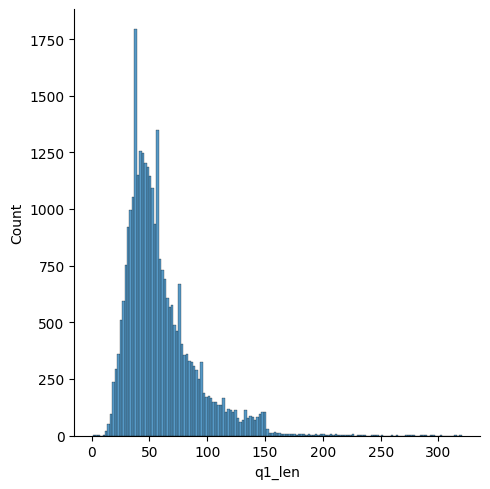

In [45]:
# Analysis of features
sns.displot(new_df['q1_len'])
print('minimum characters',new_df['q1_len'].min())
print('maximum characters',new_df['q1_len'].max())
print('average num of characters',int(new_df['q1_len'].mean()))

minimum characters 1
maximum characters 1151
average num of characters 60


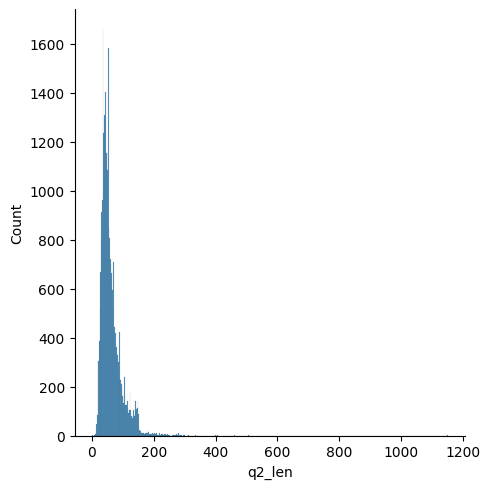

In [46]:
sns.displot(new_df['q2_len'])
print('minimum characters',new_df['q2_len'].min())
print('maximum characters',new_df['q2_len'].max())
print('average num of characters',int(new_df['q2_len'].mean()))

minimum words 1
maximum words 63
average num of words 10


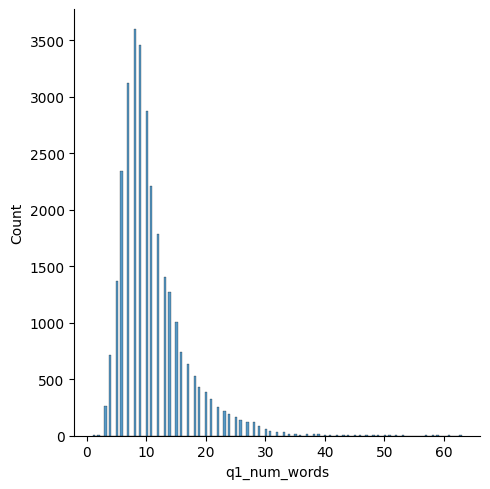

In [47]:
sns.displot(new_df['q1_num_words'])
print('minimum words',new_df['q1_num_words'].min())
print('maximum words',new_df['q1_num_words'].max())
print('average num of words',int(new_df['q1_num_words'].mean()))

minimum words 1
maximum words 237
average num of words 11


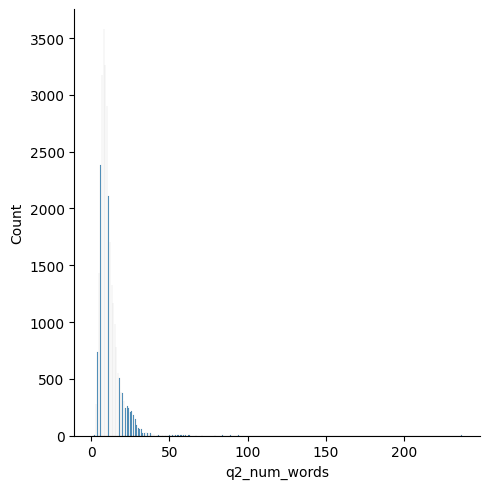

In [48]:
sns.displot(new_df['q2_num_words'])
print('minimum words',new_df['q2_num_words'].min())
print('maximum words',new_df['q2_num_words'].max())
print('average num of words',int(new_df['q2_num_words'].mean()))

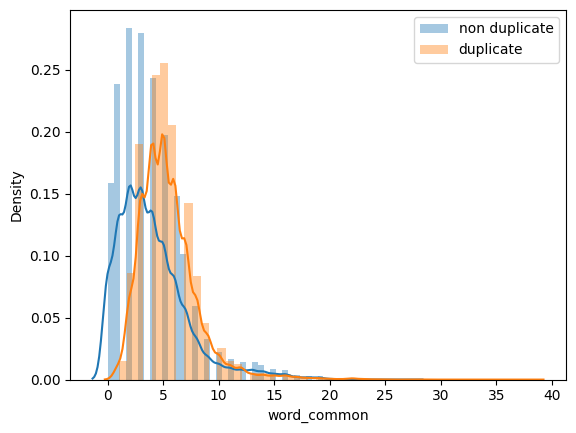

In [49]:
# common words
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_common'],label='duplicate')
plt.legend()
plt.show()

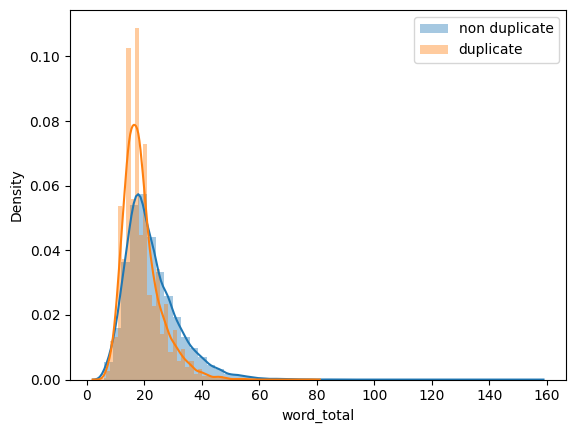

In [50]:
# total words
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_total'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_total'],label='duplicate')
plt.legend()
plt.show()

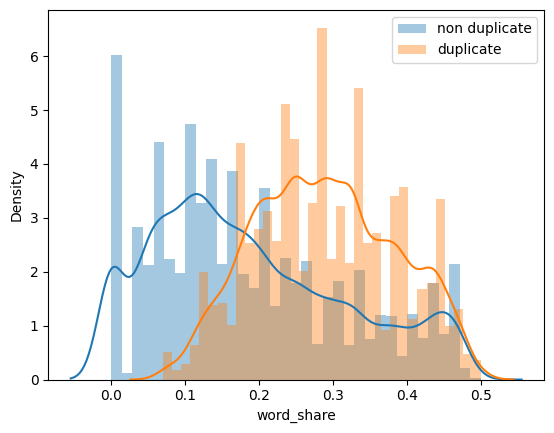

In [51]:
# word share
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [52]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
121827,How could the U.S. reform its education system?,Will the United States ever reform their educa...
117788,Can meth use be controlled by taking Ativan an...,How long does meth stay detectable in the body...
24566,What do Balaji Viswanathan and Khalid Elhassan...,What does Balaji Viswanathan think about Qnet?
147532,What would happen if Earth lost its gravity fo...,Lets say that gravity turned off for 5 minutes...
41716,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my American Staffy/Kelpie mix afraid of...


In [53]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
121827,1.0,47,58,8,9,4,17,0.24
117788,0.0,148,63,27,11,1,34,0.03
24566,0.0,67,46,11,7,4,18,0.22
147532,1.0,105,100,19,20,8,38,0.21
41716,1.0,58,52,9,9,7,18,0.39


In [54]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [55]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [56]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
121827,1.0,47,58,8,9,4,17,0.24,0,0,...,0,0,0,0,0,0,0,0,0,0
117788,0.0,148,63,27,11,1,34,0.03,0,0,...,0,0,0,0,0,0,0,0,0,0
24566,0.0,67,46,11,7,4,18,0.22,0,0,...,0,0,0,0,0,0,0,0,0,0
147532,1.0,105,100,19,20,8,38,0.21,0,0,...,0,0,0,0,0,0,0,0,0,0
41716,1.0,58,52,9,9,7,18,0.39,0,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

In [59]:
accuracy_score(y_test,y_pred)

0.7703333333333333

In [60]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)

In [61]:
accuracy_score(y_test,y_pred)

0.7728333333333334

# **Advanced Features**

1. **Token Features**

cwc_min: This is the ratio of the number of common words to the length of


the smaller question

cwc_max: This is the ratio of the number of common words to the length of the larger question

csc_min: This is the ratio of the number of common stop words to the smaller stop word count among the two questions

csc_max: This is the ratio of the number of common stop words to the larger stop word count among the two questions

ctc_min: This is the ratio of the number of common tokens to the smaller token count among the two questions

ctc_max: This is the ratio of the number of common tokens to the larger token count among the two questions

last_word_eq: 1 if the last word in the two questions is same, 0 otherwise

first_word_eq: 1 if the first word in the two questions is same, 0 otherwise



2. **Length Based Features**

mean_len: Mean of the length of the two questions (number of words)

abs_len_diff: Absolute difference between the length of the two questions (number of words)

longest_substr_ratio: Ratio of the length of the longest substring among the two questions to the length of the smaller question

3. **Fuzzy Features**

fuzz_ratio: fuzz_ratio score from fuzzywuzzy

fuzz_partial_ratio: fuzz_partial_ratio from fuzzywuzzy

token_sort_ratio: token_sort_ratio from fuzzywuzzy

token_set_ratio: token_set_ratio from fuzzywuzzy